### <center>Health Monitoring</center>

In [41]:
## Importing dataset and modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import joblib
from sklearn.preprocessing import StandardScaler
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from xgboost.callback import EarlyStopping

## Importing 3 models for comparison
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier


data=pd.read_csv("./DataSet/ECG_Arrhythmia_kaggle/MIT-BIH Arrhythmia Database.csv")
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 100689 entries, 0 to 100688
Data columns (total 34 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   record          100689 non-null  int64  
 1   type            100689 non-null  str    
 2   0_pre-RR        100689 non-null  int64  
 3   0_post-RR       100689 non-null  float64
 4   0_pPeak         100689 non-null  float64
 5   0_tPeak         100689 non-null  float64
 6   0_rPeak         100689 non-null  float64
 7   0_sPeak         100689 non-null  float64
 8   0_qPeak         100689 non-null  float64
 9   0_qrs_interval  100689 non-null  int64  
 10  0_pq_interval   100689 non-null  int64  
 11  0_qt_interval   100689 non-null  int64  
 12  0_st_interval   100689 non-null  int64  
 13  0_qrs_morph0    100689 non-null  float64
 14  0_qrs_morph1    100689 non-null  float64
 15  0_qrs_morph2    100689 non-null  float64
 16  0_qrs_morph3    100689 non-null  float64
 17  0_qrs_morph4    10068

In [42]:
## Dropping irrelavant data
dropset=["record"]
data=data.drop(columns=dropset)
print(data.head())

  type  0_pre-RR  0_post-RR   0_pPeak   0_tPeak   0_rPeak   0_sPeak   0_qPeak  \
0    N        76      313.0  0.074347 -0.160548  1.036401 -0.285662 -0.026824   
1    N       313      315.0 -0.052079 -0.264784  0.886597 -0.366298 -0.059710   
2    N       315      321.0 -0.062151 -0.296983  0.991859 -0.410306 -0.065686   
3    N       321      336.0 -0.063322 -0.281386  1.034903 -0.403880 -0.071750   
4    N       336      344.0 -0.062915  1.046914  1.046408  1.046408 -0.074639   

   0_qrs_interval  0_pq_interval  ...   1_qPeak  1_qrs_interval  \
0              41             18  ...  0.025930               2   
1              21              4  ... -0.042009              26   
2              22              3  ...  0.009528               3   
3              22              4  ... -0.020536               6   
4              11              4  ...  0.016053              16   

   1_pq_interval  1_qt_interval  1_st_interval  1_qrs_morph0  1_qrs_morph1  \
0             18             22 

In [43]:
## Viewing Null values
print(data.isnull().sum())

type              0
0_pre-RR          0
0_post-RR         0
0_pPeak           0
0_tPeak           0
0_rPeak           0
0_sPeak           0
0_qPeak           0
0_qrs_interval    0
0_pq_interval     0
0_qt_interval     0
0_st_interval     0
0_qrs_morph0      0
0_qrs_morph1      0
0_qrs_morph2      0
0_qrs_morph3      0
0_qrs_morph4      0
1_pre-RR          0
1_post-RR         0
1_pPeak           0
1_tPeak           0
1_rPeak           0
1_sPeak           0
1_qPeak           0
1_qrs_interval    0
1_pq_interval     0
1_qt_interval     0
1_st_interval     0
1_qrs_morph0      0
1_qrs_morph1      0
1_qrs_morph2      0
1_qrs_morph3      0
1_qrs_morph4      0
dtype: int64


In [44]:
## Get unique values of type
print(data.type.unique())
Le=LabelEncoder()
data["target"] = Le.fit_transform(data["type"]) ## Perform numeric encoding
print(data.head())
x=data.drop(columns=["target","type"])
y=data["target"]

<StringArray>
['N', 'Q', 'SVEB', 'VEB', 'F']
Length: 5, dtype: str
  type  0_pre-RR  0_post-RR   0_pPeak   0_tPeak   0_rPeak   0_sPeak   0_qPeak  \
0    N        76      313.0  0.074347 -0.160548  1.036401 -0.285662 -0.026824   
1    N       313      315.0 -0.052079 -0.264784  0.886597 -0.366298 -0.059710   
2    N       315      321.0 -0.062151 -0.296983  0.991859 -0.410306 -0.065686   
3    N       321      336.0 -0.063322 -0.281386  1.034903 -0.403880 -0.071750   
4    N       336      344.0 -0.062915  1.046914  1.046408  1.046408 -0.074639   

   0_qrs_interval  0_pq_interval  ...  1_qrs_interval  1_pq_interval  \
0              41             18  ...               2             18   
1              21              4  ...              26             27   
2              22              3  ...               3              8   
3              22              4  ...               6              9   
4              11              4  ...              16              5   

   1_qt_inter

In [45]:
## Splitting the data for training and testing
xtrain,xtemp,ytrain,ytemp=train_test_split(x,y,test_size=0.3,random_state=60)
xval,xtest,yval,ytest=train_test_split(xtemp,ytemp,test_size=0.5,random_state=60)
model_paths = {
    "xgb": Path("models/xgb.json"),
    "rf": Path("models/rf.pkl"),
    "gb": Path("models/gb.pkl"),
}
## Check if models exist
if model_paths["xgb"].exists():
    XG=XGBClassifier()
    XG.load_model(model_paths["xgb"])
    print("XGB found and loaded")
else:
    print("XGB not found.... Creating XGB..")
    XG=XGBClassifier()
    XG = XGBClassifier(
    n_jobs=-1,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.5,
    reg_lambda=2,
    random_state=60,
    eval_metric='mlogloss',
    objective='multi:softprob',
    early_stopping_rounds=50
)
    ## Train the model
    XG.fit(xtrain,ytrain,eval_set=[(xval, yval)])
    XG.save_model(model_paths["xgb"])

## Gradient boost
if model_paths["gb"].exists():
    GB=joblib.load(model_paths["gb"])
    print("Gradient Boost model found and loaded")
else:
    GB=GradientBoostingClassifier(n_estimators=100,learning_rate=0.05,max_depth=3)
    ## Train the model
    GB.fit(xtrain,ytrain)
    joblib.dump(GB,model_paths["gb"])
    print("GB not found.... Creating GB..")
## Random Forest
if model_paths["rf"].exists():
    RF=joblib.load(model_paths["rf"])
    print("Random Forest found and loaded")
else:
    RF=RandomForestClassifier(n_estimators=100,max_depth=5,random_state=42)
    ## Train the model 
    RF.fit(xtrain,ytrain)
    joblib.dump(RF,model_paths["rf"])
    print("Random Forest not found.... Creating Random Forest..")
scaler=StandardScaler()

XGB not found.... Creating XGB..
[0]	validation_0-mlogloss:0.39684
[1]	validation_0-mlogloss:0.37762
[2]	validation_0-mlogloss:0.36088
[3]	validation_0-mlogloss:0.34641
[4]	validation_0-mlogloss:0.33316
[5]	validation_0-mlogloss:0.32303
[6]	validation_0-mlogloss:0.31232
[7]	validation_0-mlogloss:0.30249
[8]	validation_0-mlogloss:0.29362
[9]	validation_0-mlogloss:0.28517
[10]	validation_0-mlogloss:0.27734
[11]	validation_0-mlogloss:0.27014
[12]	validation_0-mlogloss:0.26296
[13]	validation_0-mlogloss:0.25618
[14]	validation_0-mlogloss:0.25012
[15]	validation_0-mlogloss:0.24419
[16]	validation_0-mlogloss:0.23872
[17]	validation_0-mlogloss:0.23347
[18]	validation_0-mlogloss:0.22832
[19]	validation_0-mlogloss:0.22351
[20]	validation_0-mlogloss:0.21883
[21]	validation_0-mlogloss:0.21450
[22]	validation_0-mlogloss:0.21035
[23]	validation_0-mlogloss:0.20622
[24]	validation_0-mlogloss:0.20243
[25]	validation_0-mlogloss:0.19862
[26]	validation_0-mlogloss:0.19508
[27]	validation_0-mlogloss:0.191

In [51]:
## Validating models
XG_val_predict=XG.predict(xval)
GB_val_predict=GB.predict(xval)
RF_val_predict=RF.predict(xval)


## Testing models
XG_predict=XG.predict(xtest)
GB_predict=GB.predict(xtest)
RF_predict=RF.predict(xtest)

## Store validation accuracy in a list
accV=list()
accV.append(accuracy_score(yval,XG_val_predict)*100)
accV.append(accuracy_score(yval,GB_val_predict)*100)
accV.append(accuracy_score(yval,RF_val_predict)*100)

## Store testing accuracy in a list
acc=list()
acc.append(accuracy_score(ytest,XG_predict)*100)
acc.append(accuracy_score(ytest,GB_predict)*100)
acc.append(accuracy_score(ytest,RF_predict)*100)


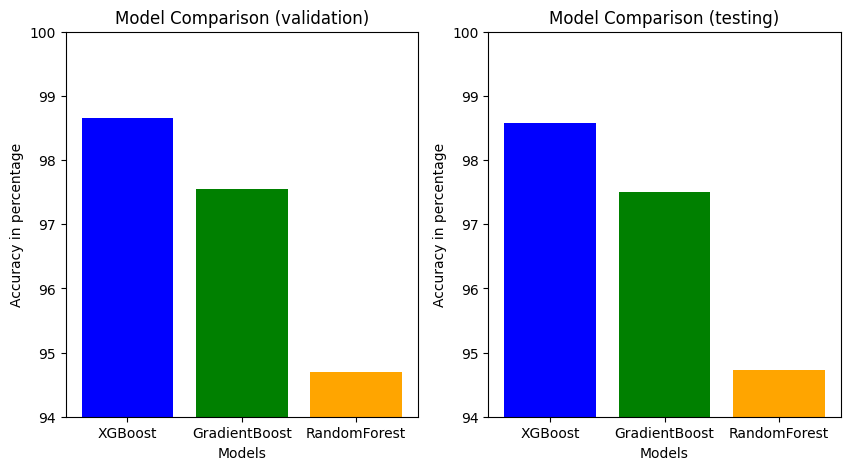

In [53]:
models = ["XGBoost", "GradientBoost", "RandomForest"]
colors = ["blue", "green", "orange"]
## Plot graphs
fig,axis=plt.subplots(1,2,figsize=(10,5))

axis[0].bar(models, accV,color=colors)
axis[0].set_ylim(94,100)
axis[0].set_xlabel("Models")
axis[0].set_ylabel("Accuracy in percentage")
axis[0].set_title("Model Comparison (validation)")

axis[1].bar(models, acc,color=colors)
axis[1].set_ylim(94,100)
axis[1].set_xlabel("Models")
axis[1].set_ylabel("Accuracy in percentage")
axis[1].set_title("Model Comparison (testing)")
plt.show()

In [48]:
## Decoding
DXG=Le.inverse_transform(XG_predict)
print(DXG)

['N' 'N' 'N' ... 'SVEB' 'N' 'N']
